פרויקט מדעי הנתונים הכפר הירוק כיתה י

עידן עטר ת"ז 318074846

שם מורה: ענת שפיר

מטרת מחקר: לחזות אם תלמיד נשר מאוניברסיטה או לא

https://www.kaggle.com/datasets/meharshanali/student-dropout-prediction-dataset

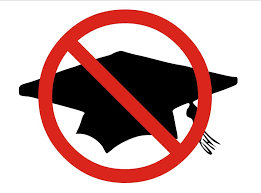

פירוט על המאגר

Student_ID: מזהה סטודנט ייחודי.

Age: גיל הסטודנט בשנים.

Gender: Male / Female (מין).

Family_Income: הכנסה משפחתית חודשית.

Internet_Access: Yes / No (גישה לאינטרנט).

Study_Hours_per_Day: ממוצע שעות לימוד ביום.

Attendance_Rate: אחוז נוכחות.

Assignment_Delay_Days: ממוצע ימי עיכוב בהגשת מטלות.

Travel_Time_Minutes: זמן נסיעה יומי בדקות.

Part_Time_Job: Yes / No (עבודה במשרה חלקית).

Scholarship: Yes / No (מלגה).

Stress_Index: מדד לחץ בדיווח עצמי (1–10).

GPA, Semester_GPA, CGPA: ביצועים אקדמיים (ממוצעים).

Semester: שנת לימודים נוכחית (Year 1–4).

Department: Science, Arts, Business, CS, Engineering (מחלקה/פקולטה).

Parental_Education: השכלה גבוהה ביותר של ההורים.

מאפייני סט הנתונים:

שורות: 10,000.

עמודות: 19.

שיעור נשירה (Dropout rate): 23.5%.

מכיל משתנים קטגוריאליים ומספריים כאחד.
10% משתנים חסרים

In [10]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import warnings
warnings.filterwarnings('ignore')
import itertools
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, cross_validate, cross_val_predict, RandomizedSearchCV, GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, ConfusionMatrixDisplay,
    classification_report
)
from imblearn.over_sampling import SMOTE
from collections import Counter
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.neural_network import MLPClassifier

נעשה אינטרגציה לנתונים מהמאגר מידע

In [11]:
# @title
path = kagglehub.dataset_download("meharshanali/student-dropout-prediction-dataset")
csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]
df = pd.read_csv(os.path.join(path, csv_files[0]))

print("הנתונים נטענו בהצלחה!")
print(df.head())

Using Colab cache for faster access to the 'student-dropout-prediction-dataset' dataset.
הנתונים נטענו בהצלחה!
   Student_ID   Age  Gender  Family_Income Internet_Access  \
0           1  22.1    Male        25000.0             Yes   
1           2  20.7    Male        25000.0             Yes   
2           3  22.4    Male        40183.0             Yes   
3           4  24.4    Male            NaN             Yes   
4           5  20.5  Female        25319.0             Yes   

   Study_Hours_per_Day  Attendance_Rate  Assignment_Delay_Days  \
0                 3.36             86.1                      2   
1                 4.30             68.0                      2   
2                 4.40             70.9                      0   
3                  NaN             82.2                      2   
4                 4.19             75.7                      1   

   Travel_Time_Minutes Part_Time_Job Scholarship  Stress_Index   GPA  \
0                 20.4           Yes          N

ניקוי  וסידור נתונים

In [12]:
print("ערכים חסרים לפי עמודה:")
print(df.isnull().sum())
print(f"\nאחוז השורות שיוסרו: {df.isnull().any(axis=1).mean():.1%}")
# @title
df_cleaned = df.dropna()

# הדפסת סיכום
print(f"שורות לפני ניקוי: {len(df)}")
print(f"שורות אחרי ניקוי: {len(df_cleaned)}")

ערכים חסרים לפי עמודה:
Student_ID                 0
Age                        0
Gender                     0
Family_Income            500
Internet_Access            0
Study_Hours_per_Day      500
Attendance_Rate            0
Assignment_Delay_Days      0
Travel_Time_Minutes        0
Part_Time_Job              0
Scholarship                0
Stress_Index             500
GPA                        0
Semester_GPA               0
CGPA                       0
Semester                   0
Department                 0
Parental_Education       511
Dropout                    0
dtype: int64

אחוז השורות שיוסרו: 9.8%
שורות לפני ניקוי: 10000
שורות אחרי ניקוי: 9020


נעשה מפה תרמית כדי שנדע לאיזה ערכים יש הכי הרבה קורלציה

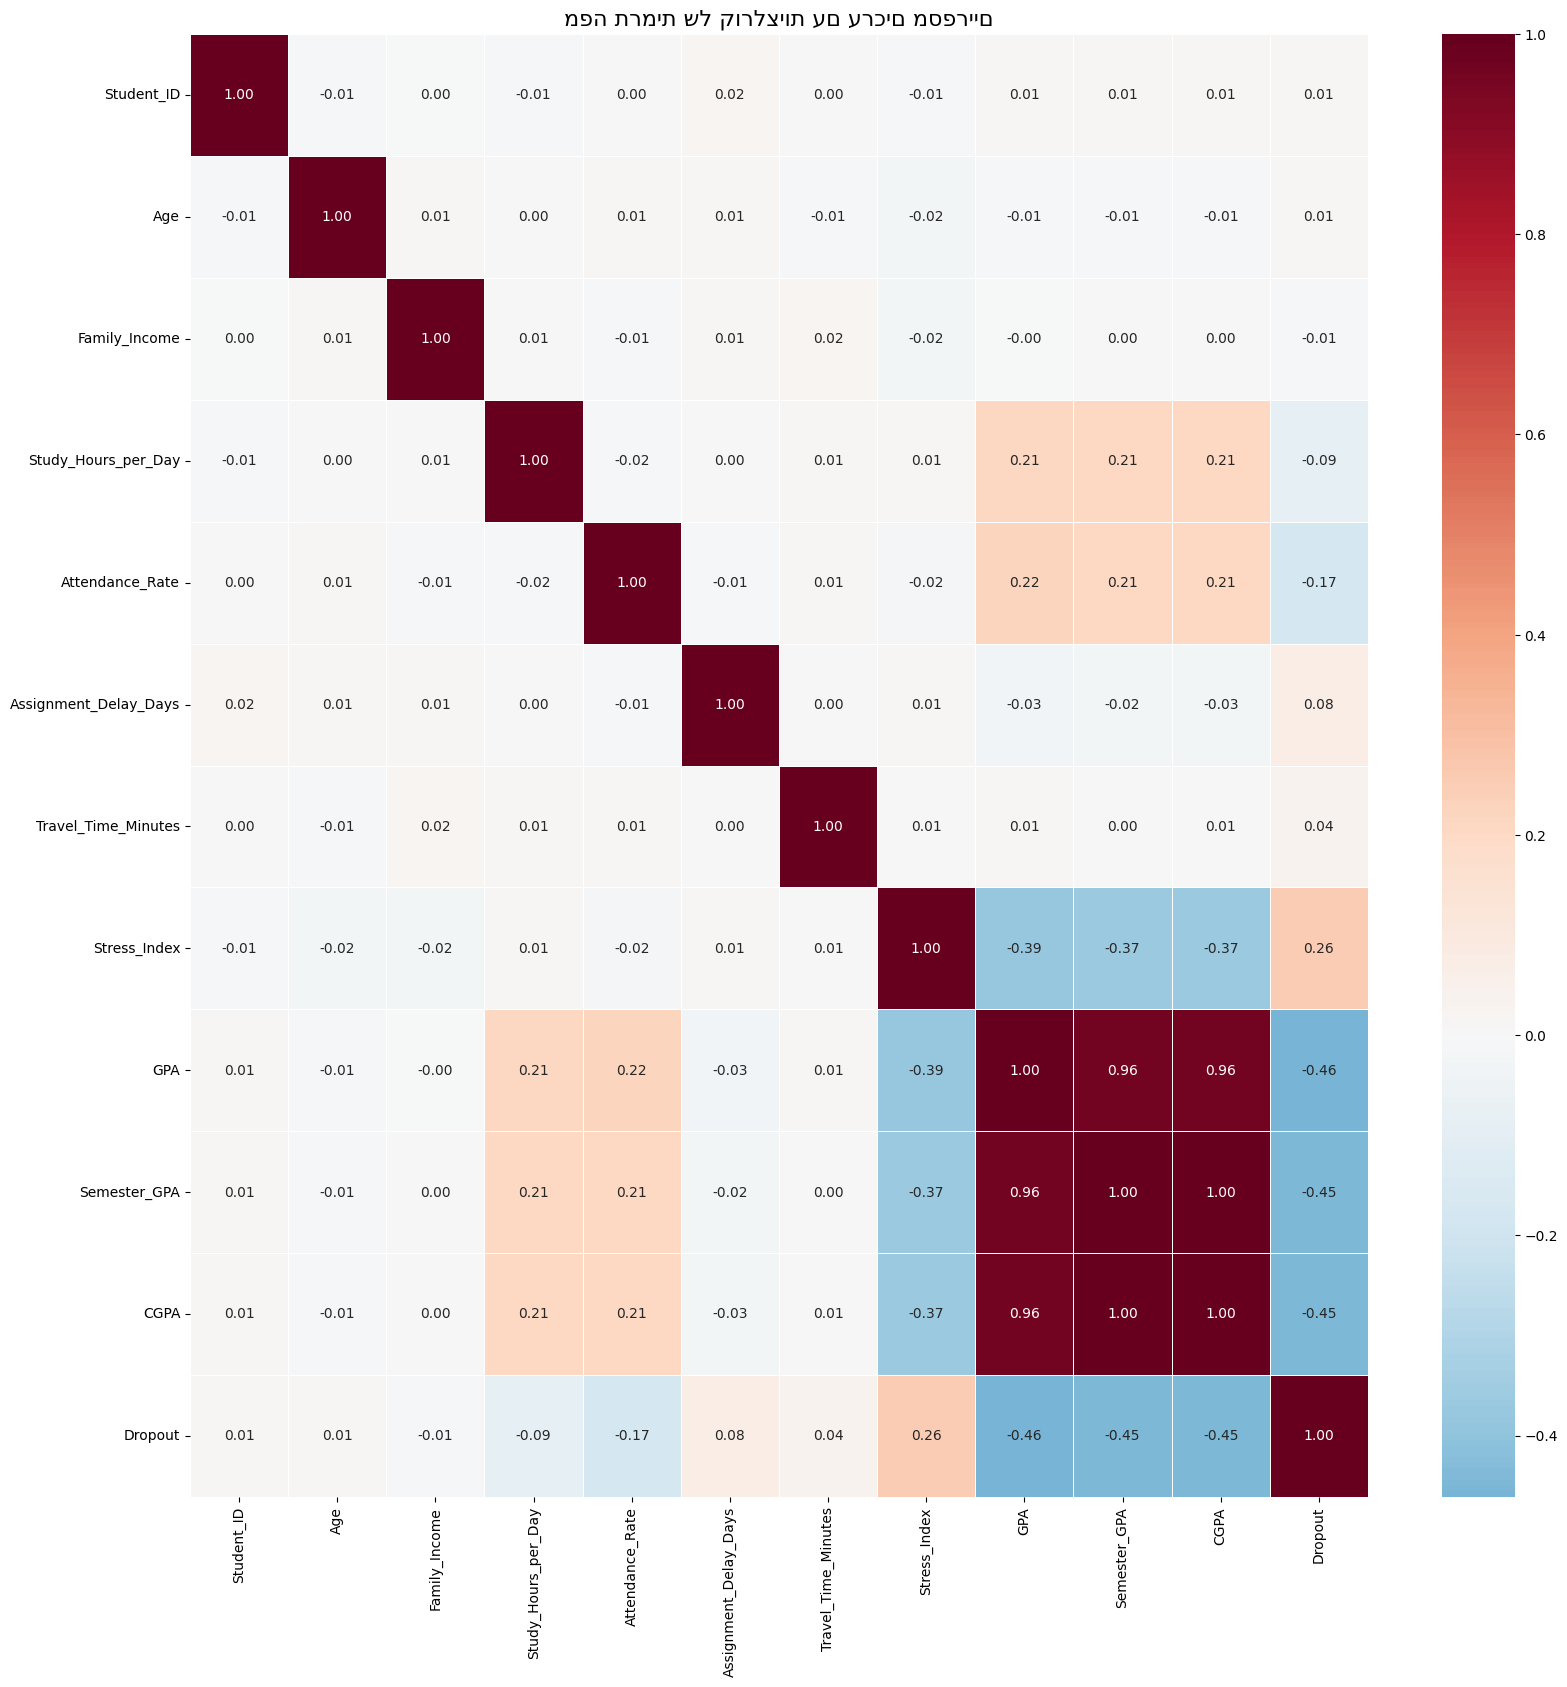

In [13]:
# @title
# 1. בחירת העמודות המספריות בלבד
numeric_df = df_cleaned.select_dtypes(include=['number'])

# 2. חישוב מטריצת הקורלציה
corr_matrix = numeric_df.corr()

top_corr_features = corr_matrix.index

# 4. יצירת המפה התרמית עם מספרים (annot=True)
plt.figure(figsize=(19, 19))
sns.heatmap(df_cleaned[top_corr_features].corr(),
            annot=True,
            fmt=".2f",
            cmap='RdBu_r',
            center=0,
            linewidths=0.5)

plt.title("מפה תרמית של קורלציות עם ערכים מספריים", fontsize=16)
plt.show()

לפי המפה הערכים בעלי הקורלציה הכי גבוהה אלו:

Stress_Index, GPA, Assignment_Delay_Days, Attendance_Rate, Study_Hours_per_Day



Total subsets to evaluate: 26
[2 feats]  Stress_Index + GPA
          F1-macro: 0.6812 ± 0.0106
[2 feats]  Stress_Index + Assignment_Delay_Days
          F1-macro: 0.5724 ± 0.0164
[2 feats]  Stress_Index + Attendance_Rate
          F1-macro: 0.5936 ± 0.0122
[2 feats]  Stress_Index + Study_Hours_per_Day
          F1-macro: 0.5809 ± 0.0155
[2 feats]  GPA + Assignment_Delay_Days
          F1-macro: 0.6506 ± 0.0083
[2 feats]  GPA + Attendance_Rate
          F1-macro: 0.6979 ± 0.0023
[2 feats]  GPA + Study_Hours_per_Day
          F1-macro: 0.6931 ± 0.0084
[2 feats]  Assignment_Delay_Days + Attendance_Rate
          F1-macro: 0.5272 ± 0.0045
[2 feats]  Assignment_Delay_Days + Study_Hours_per_Day
          F1-macro: 0.5002 ± 0.0032
[2 feats]  Attendance_Rate + Study_Hours_per_Day
          F1-macro: 0.5441 ± 0.0059
[3 feats]  Stress_Index + GPA + Assignment_Delay_Days
          F1-macro: 0.6959 ± 0.0053
[3 feats]  Stress_Index + GPA + Attendance_Rate
          F1-macro: 0.7072 ± 0.0059
[3 fea

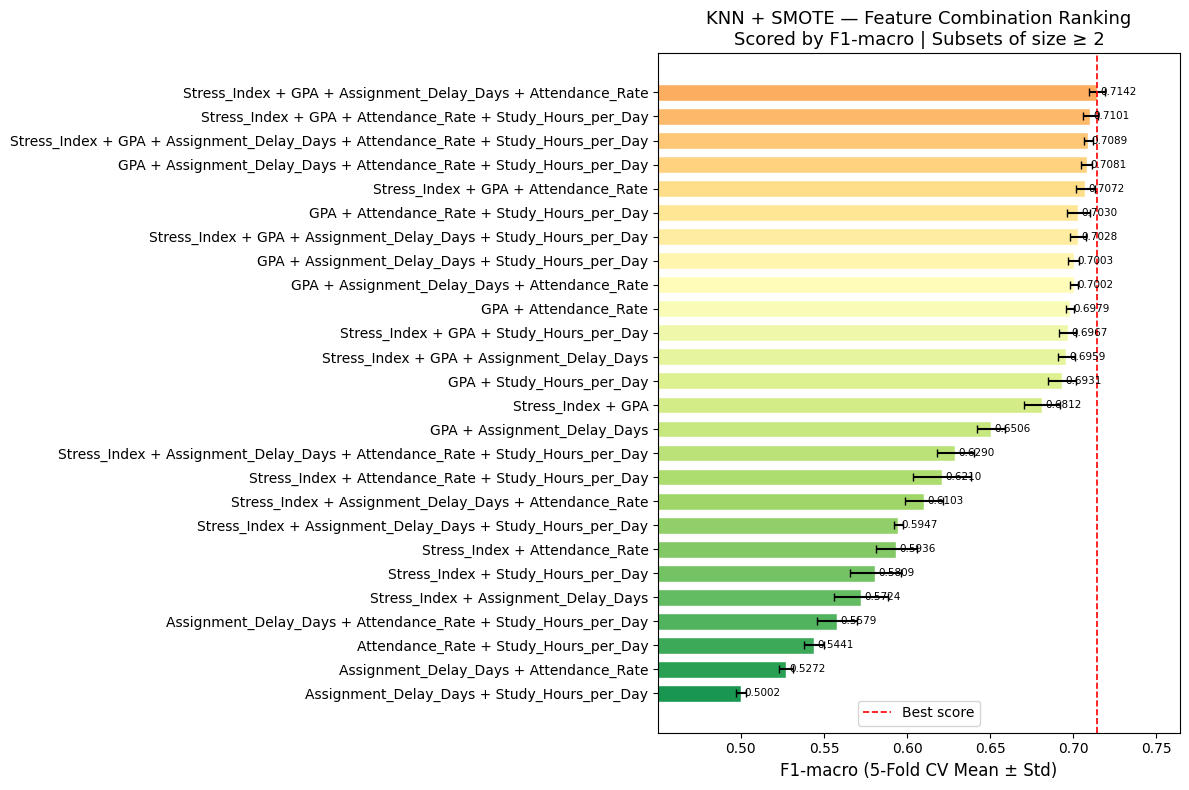

In [14]:
CANDIDATE_FEATURES = [
    "Stress_Index",
    "GPA",
    "Assignment_Delay_Days",
    "Attendance_Rate",
    "Study_Hours_per_Day",
]

TARGET = "Dropout"

# === FIX LEAKAGE: split BEFORE feature selection ===
x_all = df_cleaned[CANDIDATE_FEATURES]
y_all = df_cleaned[TARGET].values

x_train_fs, x_test_fs, y_train_fs, y_test_fs = train_test_split(
    x_all, y_all, test_size=0.2, random_state=42, stratify=y_all
)

print(f"Train size: {len(x_train_fs)}, Test size: {len(x_test_fs)}")
print(f"Feature selection will use ONLY training data (no leakage).")

subsets = []
for size in range(2, len(CANDIDATE_FEATURES) + 1):
    for combo in itertools.combinations(CANDIDATE_FEATURES, size):
        subsets.append(list(combo))

print(f"Total subsets to evaluate: {len(subsets)}")
print("=" * 65)

SMOTE_RATIO  = 0.6
CV_FOLDS     = 5
RANDOM_STATE = 42

cv_combo = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

combo_results = []

for combo in subsets:
    X_combo = x_train_fs[combo].values  # ONLY training data

    pipe = ImbPipeline([
        ("smote",  SMOTE(sampling_strategy=SMOTE_RATIO, random_state=RANDOM_STATE)),
        ("scaler", MinMaxScaler()),
        ("clf",    SVC(kernel="rbf", C=10, random_state=RANDOM_STATE)),
    ])

    scores = cross_val_score(pipe, X_combo, y_train_fs,
                             cv=cv_combo, scoring="f1_macro", n_jobs=-1)

    combo_results.append({
        "features":  combo,
        "f1_mean":   scores.mean(),
        "f1_std":    scores.std(),
        "n_features": len(combo),
    })

combo_results.sort(key=lambda r: r["f1_mean"], reverse=True)

print(f"
{'Rank':<6}{'F1-macro':<22}{'#Feat':<8}{'Features'}")
print("-" * 85)
for rank, r in enumerate(combo_results[:15], 1):
    print(f"{rank:<6}{r['f1_mean']:.4f} +/- {r['f1_std']:.4f}     {r['n_features']:<8}{r['features']}")

best = combo_results[0]
print(f"
Best subset: {best['features']}  (F1-macro: {best['f1_mean']:.4f})")


הפצרים המנצחים הם 'Stress_Index', 'GPA', 'Assignment_Delay_Days', 'Attendance_Rate'

In [15]:
FEATURES = ['Stress_Index', 'GPA', 'Assignment_Delay_Days', 'Attendance_Rate']
TARGET   = 'Dropout'

# Use the SAME split from feature selection to avoid leakage
x = df_cleaned[FEATURES]
y = df_cleaned[TARGET].values

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)

print("Dataset shape:", df_cleaned.shape)
print(f"Train: {len(x_train)}, Test: {len(x_test)}")
print("
Target distribution (train):")
print(pd.Series(y_train).value_counts())
print("
Target distribution (test):")
print(pd.Series(y_test).value_counts())


Dataset shape: (9020, 19)

Target distribution:
Dropout
0    6902
1    2118
Name: count, dtype: int64


נראה גרף המראה את ההתפלגות של המשתנים כדי להראות קורלציה באופן ויזואלי

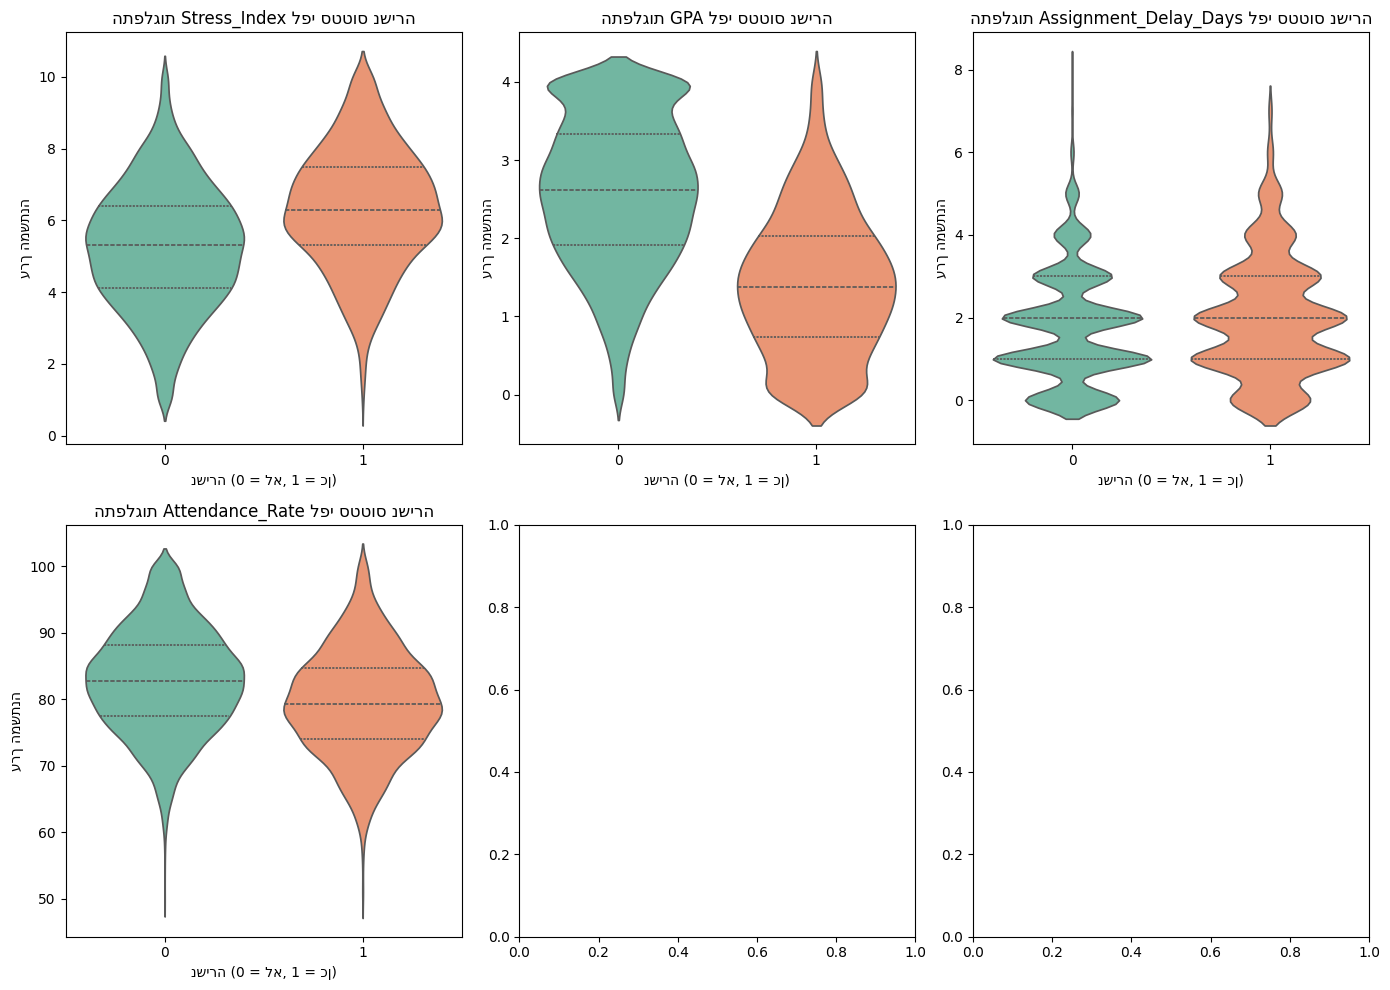

In [16]:
# @title


fig, axes = plt.subplots(2, 3, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(FEATURES):
    sns.violinplot(x='Dropout', y=col, data=df_cleaned, ax=axes[i], palette="Set2", inner="quartile")
    axes[i].set_title(f'התפלגות {col} לפי סטטוס נשירה', fontsize=12)
    axes[i].set_xlabel('נשירה (0 = לא, 1 = כן)')
    axes[i].set_ylabel('ערך המשתנה')

plt.tight_layout()
plt.show()

נראה גרף המראה את ההבדל בין הנושרים לממשיכים

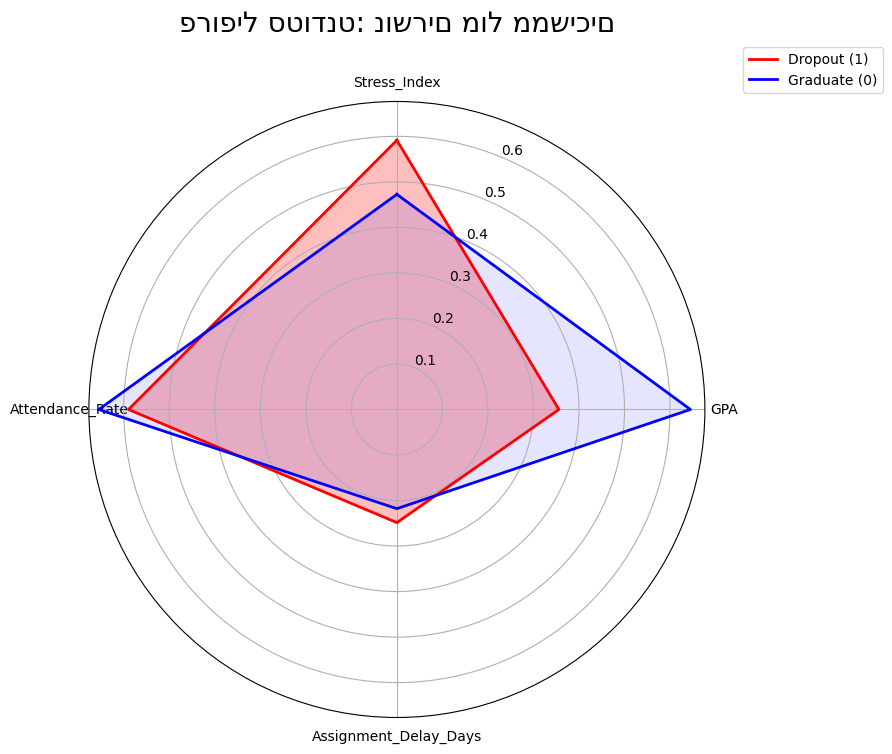

In [17]:
# @title
from sklearn.preprocessing import MinMaxScaler
# Fit scaler only on train to avoid leakage in visualization
scaler_radar = MinMaxScaler()
scaler_radar.fit(x_train[FEATURES] if hasattr(x_train, 'columns') else pd.DataFrame(x_train, columns=FEATURES))
df_radar = pd.DataFrame(scaler_radar.transform(df_cleaned[FEATURES]), columns=FEATURES)
df_radar['Dropout'] = df_cleaned['Dropout'].values

# חישוב ממוצע לכל קבוצה
categories = FEATURES
N = len(categories)

# ממוצע נושרים וממוצע ממשיכים
avg_dropout = df_radar[df_radar['Dropout'] == 1][categories].mean().tolist()
avg_graduate = df_radar[df_radar['Dropout'] == 0][categories].mean().tolist()

# סגירת המעגל של הגרף (הוספת הערך הראשון בסוף)
avg_dropout += avg_dropout[:1]
avg_graduate += avg_graduate[:1]

angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

# 2. שרטוט הגרף
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

# קבוצת הנושרים
ax.plot(angles, avg_dropout, color='red', linewidth=2, label='Dropout (1)')
ax.fill(angles, avg_dropout, color='red', alpha=0.25)

# קבוצת הממשיכים
ax.plot(angles, avg_graduate, color='blue', linewidth=2, label='Graduate (0)')
ax.fill(angles, avg_graduate, color='blue', alpha=0.1)

# הגדרות אסתטיות
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
plt.xticks(angles[:-1], categories)

plt.title('פרופיל סטודנט: נושרים מול ממשיכים', size=20, y=1.1)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.show()

נחלק לקבוצות ציונים

In [18]:
# @title

df_plot = df_cleaned.copy()
df_plot['GPA_Group'] = pd.cut(df_plot['GPA'], bins=[0, 2, 3, 4], labels=['Low', 'Medium', 'High'])

dropout_rate = df_plot.groupby('GPA_Group')['Dropout'].mean() * 100
print(dropout_rate)

stats = df_plot.groupby('Dropout')['GPA'].agg(['mean', 'median', 'min', 'max'])
print(stats)



GPA_Group
Low       42.762763
Medium    14.821067
High       4.138747
Name: Dropout, dtype: float64
             mean  median  min  max
Dropout                            
0        2.579312    2.62  0.0  4.0
1        1.423621    1.38  0.0  4.0


לפי ההרצה אפשר לראות שההבדל בין הנשירה של בינוני לנמוך הרבה יותר גדולה מההפרש בין בינוני לגבוה וזה אומר שהשפעת הציונים על אחוזי נשירה מתעצמת ככל שהציונים יורדים

אפשר לראות שהסטודנטים שנשרו היו ציונים משמעותית יותר נמוכים מאלה שלא

חלק ג

  נפתור בעיות באיזון באמצעות מציאת יחס הנתונים הטוב ביותר עם smote

In [19]:

cv_smote = StratifiedKFold(n_splits=7, shuffle=True, random_state=42)
smote_strategies = [0.5, 0.6, 0.7, 0.8,]
best_smote_ratio = None
best_smote_score = 0.0
for ratio in smote_strategies:
    pipe = ImbPipeline([
        ('smote',  SMOTE(sampling_strategy=ratio, random_state=42)),
        ('scaler', StandardScaler()),
        ('clf',    SVC(kernel='rbf', C=10, random_state=42)),
    ])
    scores = cross_val_score(pipe, x_train, y_train,
                             cv=cv_smote, scoring='f1_macro', n_jobs=-1)
    print(f"  ratio={ratio:.1f}  →  F1-macro: {scores.mean():.4f} ± {scores.std():.4f}")
    if scores.mean() > best_smote_score:
        best_smote_score = scores.mean()
        best_smote_ratio = ratio
if best_smote_ratio is None:
    best_smote_ratio = smote_strategies[0]
print(f"\n✓ Best SMOTE ratio: {best_smote_ratio}  (CV F1-macro: {best_smote_score:.4f})")


  ratio=0.5  →  F1-macro: 0.7090 ± 0.0176
  ratio=0.6  →  F1-macro: 0.7110 ± 0.0165
  ratio=0.7  →  F1-macro: 0.7075 ± 0.0170
  ratio=0.8  →  F1-macro: 0.7014 ± 0.0139

✓ Best SMOTE ratio: 0.6  (CV F1-macro: 0.7110)


נכין דוח מדדי הביצועים ומטריצת בלבול

In [20]:
# @title

def evaluate_model(name, y_test, y_pred):
    """
    7.2 - מטריצת בלבול + מדדי ביצוע לסיווג
    """
    print(f"\n{'=' * 55}")
    print(f"  {name}")
    print(f"{'=' * 55}")

    # 7.2.1 - Accuracy
    acc = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {acc:.4f}")

    # 7.2.2 + 7.2.3 - Precision / Recall / F1 (macro + weighted)
    prec_macro = precision_score(y_test, y_pred, average='macro',    zero_division=0)
    rec_macro  = recall_score   (y_test, y_pred, average='macro',    zero_division=0)
    f1_macro   = f1_score       (y_test, y_pred, average='macro',    zero_division=0)
    prec_w     = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec_w      = recall_score   (y_test, y_pred, average='weighted', zero_division=0)
    f1_w       = f1_score       (y_test, y_pred, average='weighted', zero_division=0)

    print(f"\n{'Metric':<15} {'Macro (חשבוני)':<20} {'Weighted (משוקלל)'}")
    print(f"{'Precision':<15} {prec_macro:<20.4f} {prec_w:.4f}")
    print(f"{'Recall':<15} {rec_macro:<20.4f} {rec_w:.4f}")
    print(f"{'F1':<15} {f1_macro:<20.4f} {f1_w:.4f}")

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, digits=4))

    # מטריצת בלבול - שמירה לתמונה
    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred)).plot(ax=ax, colorbar=False)
    ax.set_title(f"Confusion Matrix\n{name}", fontsize=9)
    plt.tight_layout()
    plt.savefig(f"cm_{name.replace(' ', '_').replace('/', '-')}.png", dpi=100)
    plt.show()

    return {
        'accuracy':           acc,
        'f1_macro':           f1_macro,
        'f1_weighted':        f1_w,
        'precision_macro':    prec_macro,
        'precision_weighted': prec_w,
        'recall_macro':       rec_macro,
        'recall_weighted':    rec_w,
    }

 בתיבה הבאה יש אימון וחיזוי כל המודלים, חקר היפרמטרים בכל מודל ובדיקת הנרמול הטוב ביותר. ובנוסף לכך משווה את המודלים למודל טיפש המנחש שאף אחד לא נשר.

In [23]:
from sklearn.dummy import DummyClassifier
dummy_majority = DummyClassifier(strategy='most_frequent', random_state=42)
dummy_majority.fit(x_train, y_train)
y_pred_dummy = dummy_majority.predict(x_test)
print("=== Baseline (most_frequent) ===")
evaluate_model("Dummy/majority", y_test, y_pred_dummy)

cv_knn_inner  = StratifiedKFold(n_splits=5,  shuffle=True, random_state=42)
cv_knn_outer  = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
cv_fast_inner = StratifiedKFold(n_splits=3,  shuffle=True, random_state=42)
cv_fast_outer = StratifiedKFold(n_splits=5,  shuffle=True, random_state=42)

scalers = {
    'mn':  MinMaxScaler(),
    'std': StandardScaler(),
}
tuned_results = {}
best_models   = {}

for scaler_name, scaler_obj in scalers.items():

    print(f"\n\n{'#'*70}")
    print(f"  SCALER: {scaler_name.upper()}")
    print(f"{'#'*70}")

    # ── KNN ──────────────────────────────────────────────────────────────────
    print(f"\n{'='*62}")
    print(f"  KNN — GridSearchCV (inner 5-Fold) / {scaler_name}")
    print(f"{'='*62}")

    knn_pipe = ImbPipeline([
        ('smote',  SMOTE(sampling_strategy=best_smote_ratio, random_state=42)),
        ('scaler', scaler_obj),
        ('clf',    KNeighborsClassifier()),
    ])
    knn_grid = {
        'clf__n_neighbors': [5, 15, 25, 35, 45, 55, 65, 75, 85, 95],
        'clf__weights':     ['uniform', 'distance'],
        'clf__metric':      ['euclidean', 'manhattan'],
    }
    knn_search = GridSearchCV(knn_pipe, knn_grid,
                              cv=cv_knn_inner, scoring='f1_macro',
                              n_jobs=-1, verbose=0)
    knn_search.fit(x_train, y_train)
    y_pred = knn_search.best_estimator_.predict(x_test)
    print(f"Best params       : {knn_search.best_params_}")
    print(f"Inner-CV F1-macro : {knn_search.best_score_:.4f}")
    result = evaluate_model(f"KNN / {scaler_name}", y_test, y_pred)
    outer = cross_val_score(knn_search.best_estimator_, x_train, y_train,
                            cv=cv_knn_outer, scoring='f1_macro', n_jobs=-1)
    print(f"Outer 10-Fold CV  : {outer.mean():.4f} ± {outer.std():.4f}")
    key = f"KNN/{scaler_name}"
    tuned_results[key] = {**result, 'best_params': knn_search.best_params_,
                          'inner_cv_f1': knn_search.best_score_,
                          'outer_cv_f1_mean': outer.mean(), 'outer_cv_f1_std': outer.std()}
    best_models[key] = knn_search.best_estimator_

    # ── SVM ──────────────────────────────────────────────────────────────────
    print(f"\n{'='*62}")
    print(f"  SVM — RandomizedSearchCV (inner 3-Fold, n_iter=10) / {scaler_name}")
    print(f"{'='*62}")

    svm_pipe = ImbPipeline([
        ('smote',  SMOTE(sampling_strategy=best_smote_ratio, random_state=42)),
        ('scaler', scaler_obj),
        ('clf',    SVC(random_state=42)),
    ])
    svm_dist = {
        'clf__C':      [1, 10, 100],
        'clf__kernel': ['linear', 'rbf'],
        'clf__gamma':  ['scale', 'auto'],
    }
    svm_search = RandomizedSearchCV(svm_pipe, svm_dist, n_iter=10,
                                    cv=cv_fast_inner, scoring='f1_macro',
                                    n_jobs=-1, random_state=42, verbose=0)
    svm_search.fit(x_train, y_train)
    y_pred = svm_search.best_estimator_.predict(x_test)
    print(f"Best params       : {svm_search.best_params_}")
    print(f"Inner-CV F1-macro : {svm_search.best_score_:.4f}")
    result = evaluate_model(f"SVM / {scaler_name}", y_test, y_pred)
    outer = cross_val_score(svm_search.best_estimator_, x_train, y_train,
                            cv=cv_fast_outer, scoring='f1_macro', n_jobs=-1)
    print(f"Outer 5-Fold CV   : {outer.mean():.4f} ± {outer.std():.4f}")
    key = f"SVM/{scaler_name}"
    tuned_results[key] = {**result, 'best_params': svm_search.best_params_,
                          'inner_cv_f1': svm_search.best_score_,
                          'outer_cv_f1_mean': outer.mean(), 'outer_cv_f1_std': outer.std()}
    best_models[key] = svm_search.best_estimator_

    # ── MLP ──────────────────────────────────────────────────────────────────
    print(f"\n{'='*62}")
    print(f"  MLP — RandomizedSearchCV (inner 3-Fold, n_iter=10) / {scaler_name}")
    print(f"{'='*62}")

    mlp_pipe = ImbPipeline([
        ('smote',  SMOTE(sampling_strategy=best_smote_ratio, random_state=42)),
        ('scaler', scaler_obj),
        ('clf',    MLPClassifier(max_iter=200, early_stopping=True, random_state=42)),
    ])
    mlp_dist = {
        'clf__hidden_layer_sizes': [(64,), (128,), (64, 32), (128, 64)],
        'clf__activation':         ['relu', 'tanh'],
        'clf__learning_rate_init': [0.001, 0.01],
    }
    mlp_search = RandomizedSearchCV(mlp_pipe, mlp_dist, n_iter=10,
                                    cv=cv_fast_inner, scoring='f1_macro',
                                    n_jobs=-1, random_state=42, verbose=0)
    mlp_search.fit(x_train, y_train)
    y_pred = mlp_search.best_estimator_.predict(x_test)
    print(f"Best params       : {mlp_search.best_params_}")
    print(f"Inner-CV F1-macro : {mlp_search.best_score_:.4f}")
    result = evaluate_model(f"MLP / {scaler_name}", y_test, y_pred)
    outer = cross_val_score(mlp_search.best_estimator_, x_train, y_train,
                            cv=cv_fast_outer, scoring='f1_macro', n_jobs=-1)
    print(f"Outer 5-Fold CV   : {outer.mean():.4f} ± {outer.std():.4f}")
    key = f"MLP/{scaler_name}"
    tuned_results[key] = {**result, 'best_params': mlp_search.best_params_,
                          'inner_cv_f1': mlp_search.best_score_,
                          'outer_cv_f1_mean': outer.mean(), 'outer_cv_f1_std': outer.std()}
    best_models[key] = mlp_search.best_estimator_

# ── Summary ───────────────────────────────────────────────────────────────────
print("\n\n" + "="*90)
print("FINAL RESULTS SUMMARY")
print("="*90)
print(f"{'Model':<22}{'Test Accuracy':<16}{'Test F1-Macro':<16}{'CV F1'}")
print("-"*90)
for mn, r in tuned_results.items():
    cv_str = f"{r['outer_cv_f1_mean']:.4f} ± {r['outer_cv_f1_std']:.4f}"
    print(f"{mn:<22}{r['accuracy']:<16.4f}{r['f1_macro']:<16.4f}{cv_str}")
print()
best_key = max(tuned_results, key=lambda k: tuned_results[k]['f1_macro'])
print(f"\n{'='*60}")
print(f"המודל המנצח: {best_key}")
print(f"F1-macro על test: {tuned_results[best_key]['f1_macro']:.4f}")
print(f"היפרפרמטרים: {tuned_results[best_key]['best_params']}")
print(f"{'='*60}")
all_results = tuned_results

=== Baseline (most_frequent) ===

  Dummy/majority
Accuracy: 0.7589

Metric          Macro (חשבוני)       Weighted (משוקלל)
Precision       0.3794               0.5759
Recall          0.5000               0.7589
F1              0.4315               0.6548

Classification Report:
              precision    recall  f1-score   support

           0     0.7589    1.0000    0.8629      1369
           1     0.0000    0.0000    0.0000       435

    accuracy                         0.7589      1804
   macro avg     0.3794    0.5000    0.4315      1804
weighted avg     0.5759    0.7589    0.6548      1804



######################################################################
  SCALER: MN
######################################################################

  KNN — GridSearchCV (inner 5-Fold) / mn
Best params       : {'clf__metric': 'euclidean', 'clf__n_neighbors': 75, 'clf__weights': 'uniform'}
Inner-CV F1-macro : 0.7145

  KNN / mn
Accuracy: 0.7783

Metric          Macro (חשבוני)       